<a href="https://colab.research.google.com/github/jaimejrs/avanti-bean-leaf-classification/blob/main/squad_03_bean_leaf_classification_Resnet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Projeto do Bootcamp Avanti - Machine Learning

🔹 Projeto 03

📌 Assunto: Classificação de lesões em folhas de feijão

🔗 Dataset: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification

📌 Link do Projeto: https://github.com/jaimejrs/avanti-bean-leaf-classification


### Participantes:
Cristiane Santos da Cunha

Eric Gabriel Aguiar de Alencar

Fabrício Almeida Santos

Ian Silva Nogueira

Jaime Teixeira de Araújo Júnior

Juliana Gonçalves Câmara

### ATIVIDADE-04-ETAPA-01
#### Objetivo: Apresentar informações do dataset





#### Baixar dataset do Kaggle

In [4]:
!pip install opendatasets
!pip install pandas
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.1 MB/s eta 0:00:00


In [5]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
root_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification"

In [7]:
print("Dataset encontrado:", os.path.exists(root_dir))

if os.path.exists(root_dir):
    print("\nConteúdo:")
    print(os.listdir(root_dir))

Dataset encontrado: True

Conteúdo:
['train.csv', 'classname.txt', 'val', 'val.csv', 'test', 'test.csv', 'train', 'model.pth']


In [8]:
# IMPORTAÇÕES
!pip install opencv-python

import pandas as pd
import os
import cv2
import imagehash
import matplotlib.pyplot as plt
%matplotlib inline
import random
import shutil

In [9]:
!ls

drive  sample_data


In [10]:
# estrutura do data set

print(os.listdir("/content/drive/MyDrive/bean-leaf-lesions-classification"))

['train.csv', 'classname.txt', 'val', 'val.csv', 'test', 'test.csv', 'train', 'model.pth']


In [11]:
train_df = pd.read_csv("/content/drive/MyDrive/bean-leaf-lesions-classification/train.csv")

train_df.head()

,image:FILE,category
0,train/healthy/healthy_train.98.jpg,0
1,train/healthy/healthy_train.148.jpg,0
2,train/healthy/healthy_train.306.jpg,0
3,train/healthy/healthy_train.305.jpg,0
4,train/healthy/healthy_train.40.jpg,0


In [12]:
print(train_df.columns)

Index(['image:FILE', 'category'], dtype='object')


In [13]:
# Validação

val_df = pd.read_csv("/content/drive/MyDrive/bean-leaf-lesions-classification/val.csv")

imagens_csv = set(val_df["image:FILE"])
imagens_pasta = set()

val_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification/val"

for classe in os.listdir(val_dir):
    pasta = os.path.join(val_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 133
Imagens encontradas na pasta: 133
Imagens no CSV e ausentes na pasta: 133
Imagens na pasta e ausentes no CSV: 133


In [14]:
# Ler o CSV
train_df = pd.read_csv("/content/drive/MyDrive/bean-leaf-lesions-classification/train.csv")

# Imagens listadas no CSV
imagens_csv = set(train_df["image:FILE"])

# Imagens existentes na pasta
imagens_pasta = set()

train_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification/train"

for classe in os.listdir(train_dir):
    pasta = os.path.join(train_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

# Comparação
faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 1034
Imagens encontradas na pasta: 880
Imagens no CSV e ausentes na pasta: 1034
Imagens na pasta e ausentes no CSV: 880


In [15]:
# Teste

# Pasta de teste
test_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification/test"

# Conjunto para armazenar os nomes das imagens
imagens_teste = set()

# Percorre cada classe
for classe in os.listdir(test_dir):
    pasta = os.path.join(test_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_teste.add(img)

print(f"Total de imagens de teste: {len(imagens_teste)}")

# Exibe algumas imagens
print("\nPrimeiras 10 imagens:")
for img in list(imagens_teste)[:10]:
    print(img)

Total de imagens de teste: 154

Primeiras 10 imagens:
angular_leaf_spot_train.36.jpg
healthy_train.32.jpg
angular_leaf_spot_train.196.jpg
healthy_train.286.jpg
bean_rust_train.100.jpg
angular_leaf_spot_train.50.jpg
angular_leaf_spot_train.254.jpg
healthy_train.145.jpg
healthy_train.179.jpg
healthy_train.338.jpg


In [16]:
train_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification/train"
validation_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification/val"
test_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification/test"

def contar_imagens(diretorio):
    total = 0

    for classe in os.listdir(diretorio):
        pasta = os.path.join(diretorio, classe)

        if os.path.isdir(pasta):
            total += len(os.listdir(pasta))

    return total

train = contar_imagens(train_dir)
validation = contar_imagens(val_dir)
test = contar_imagens(test_dir)

print(f"Treinamento: {train}")
print(f"Validação: {validation}")
print(f"Teste: {test}")

Treinamento: 880
Validação: 133
Teste: 154


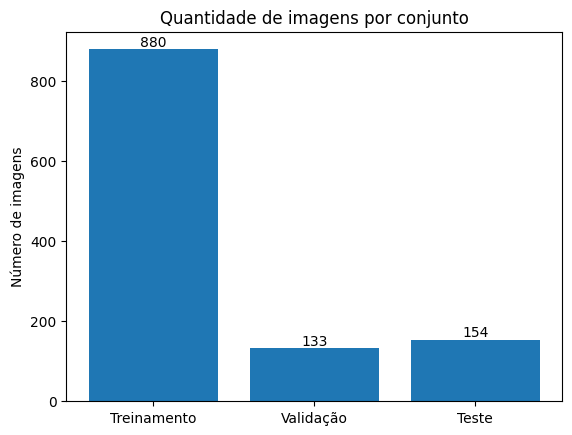

In [17]:


# Gráfico
conjuntos = ["Treinamento", "Validação", "Teste"]
quantidades = [train, validation, test]

ax = plt.bar(conjuntos, quantidades)

plt.title("Quantidade de imagens por conjunto")
plt.ylabel("Número de imagens")

for barra in ax:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        str(int(altura)),
        ha='center',
        va='bottom'
    )

plt.show()

In [18]:
from PIL import Image
count_corrupted = 0
corrupted = list()

In [19]:
dataframe_list = list()
# 'count_corrupted' and 'corrupted' are initialized in a previous cell

for dataset_folder_name in os.listdir(root_dir):
  dataset_folder_path = os.path.join(root_dir, dataset_folder_name)

  # Ensure it's a directory (e.g., 'train', 'test', 'val') and not a file like 'val.csv' or 'classname.txt'
  if os.path.isdir(dataset_folder_path):
    for class_name_folder in os.listdir(dataset_folder_path):
      class_folder_path = os.path.join(dataset_folder_path, class_name_folder)

      # Ensure it's a directory (e.g., 'healthy', 'angular_leaf_spot', 'bean_rust')
      if os.path.isdir(class_folder_path):
        for image_filename in os.listdir(class_folder_path):
          img_path = os.path.join(class_folder_path, image_filename)

          # Ensure it's an actual file and has a dot for extension splitting
          if os.path.isfile(img_path) and '.' in image_filename:
            _, image_format = image_filename.rsplit('.', 1)
            image_format = image_format.lower()
            img = cv2.imread(img_path)

            if img is not None:
              img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
              # Converter a imagem OpenCV para uma imagem do Pillow
              img_pil = Image.fromarray(img_rgb)

              # Gerar o hash da imagem (usando perceptual hash como exemplo)
              img_hash = imagehash.phash(img_pil)
              width, height, channels = img.shape
              img_corrupted = False
            else:
              count_corrupted += 1
              corrupted.append(img_path)
              img_corrupted = True
              img_hash, image_format, width, height, channels = None, None, None, None, None

            # The 'class_name_folder' is the label for the image
            dataframe_list.append([img_path, img_corrupted, img_hash, image_format, width, height, channels, class_name_folder])

In [20]:
print(f"Total de imagens corrompidas: {count_corrupted}")

if count_corrupted > 0:
    print("\nLista de imagens corrompidas:")
    for img in corrupted:
        print(img)
else:
    print("Nenhuma imagem corrompida foi encontrada.")

Total de imagens corrompidas: 0
Nenhuma imagem corrompida foi encontrada.


In [21]:
print(corrupted)
print(len(corrupted))

[]
0


In [22]:
if corrupted:
    if os.path.exists(corrupted[0]):
        os.remove(corrupted[0])
    else:
        print(f"O arquivo {corrupted[0]} não foi encontrado. Pode já ter sido removido ou não existe.")
else:
    print("Nenhum arquivo corrompido para remover.")

Nenhum arquivo corrompido para remover.


In [23]:
if corrupted:
    print(os.path.exists(corrupted[0]))
else:
    print("Nenhum arquivo corrompido na lista para verificar existência.")

Nenhum arquivo corrompido na lista para verificar existência.


In [24]:
df = pd.DataFrame(columns=['image_path', 'corrupted', 'image_hash', 'image_format', 'width', 'height', 'channels', 'label'], data = dataframe_list)

In [25]:
df.head()

,image_path,corrupted,image_hash,image_format,width,height,channels,label
0,/content/drive/MyDrive/bean-leaf-lesions-class...,False,87d87c853a42c3cf,jpg,500,500,3,bean_rust
1,/content/drive/MyDrive/bean-leaf-lesions-class...,False,95c77103e4e11f78,jpg,500,500,3,bean_rust
2,/content/drive/MyDrive/bean-leaf-lesions-class...,False,c4c60f172622bf7a,jpg,500,500,3,bean_rust
3,/content/drive/MyDrive/bean-leaf-lesions-class...,False,c1b36f769f4490a8,jpg,500,500,3,bean_rust
4,/content/drive/MyDrive/bean-leaf-lesions-class...,False,97883cff48ad1632,jpg,500,500,3,bean_rust


#### Verificar se todas as imagens estão no mesmo formato

In [26]:
import os
from collections import Counter

root = "/content/drive/MyDrive/bean-leaf-lesions-classification"

formatos = []

# Percorre todas as pastas do dataset
for conjunto in ["train", "val", "test"]:
    pasta_conjunto = os.path.join(root, conjunto)

    for classe in os.listdir(pasta_conjunto):
        pasta_classe = os.path.join(pasta_conjunto, classe)

        if not os.path.isdir(pasta_classe):
            continue

        for arquivo in os.listdir(pasta_classe):
            extensao = os.path.splitext(arquivo)[1].lower()
            formatos.append(extensao)

# Conta quantos arquivos existem de cada formato
contagem = Counter(formatos)

print("Formatos encontrados:")
for formato, quantidade in contagem.items():
    print(f"{formato}: {quantidade} imagens")

Formatos encontrados:
.jpg: 1167 imagens


In [27]:
# Tipos de imagens
pastas = {
    "Treinamento": "/content/drive/MyDrive/bean-leaf-lesions-classification",
    "Validação": "/content/drive/MyDrive/bean-leaf-lesions-classification/val",
    "Teste": "/content/drive/MyDrive/bean-leaf-lesions-classification/test"
}

for nome_pasta, diretorio in pastas.items():

    formatos = {}

    for classe in os.listdir(diretorio):
        pasta_classe = os.path.join(diretorio, classe)

        if os.path.isdir(pasta_classe):
            for arquivo in os.listdir(pasta_classe):
                extensao = os.path.splitext(arquivo)[1].lower()

                if extensao in formatos:
                    formatos[extensao] += 1
                else:
                    formatos[extensao] = 1

    print(f"\n=== {nome_pasta} ===")
    for formato, quantidade in formatos.items():
        print(f"{formato}: {quantidade} imagens")


=== Treinamento ===
: 9 imagens

=== Validação ===
.jpg: 133 imagens

=== Teste ===
.jpg: 154 imagens


##### Resumo:


Foi encontrado o arquivo 'healthy_train.120tore' como corrompido e foi excluído.

Foi avaliada a estrutura do dataset

Foi realizada a separação de 15% das imagens de treinamento para teste.

Portanto ficaram 880 imagens para treinamento, 133 imagens de validação e 154 imagens para teste.

Gerado o gráfico.

Verificado se todas as imagens estão no mesmo formato


### Consistência dos Metadados

In [28]:
#Informações estatísticas dos valores de altura, largura e canais das imagens

df.describe().loc[['mean', 'std', 'min', 'max']]

,width,height,channels
mean,500.0,500.0,3.0
std,0.0,0.0,0.0
min,500.0,500.0,3.0
max,500.0,500.0,3.0


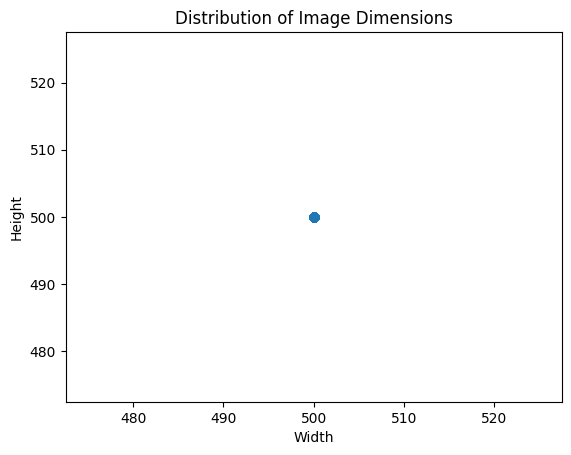

In [29]:
#Distribuição das Dimensões de Altura e Largura das Imagens

plt.scatter(df['width'], df['height'])
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Distribution of Image Dimensions')
plt.show()

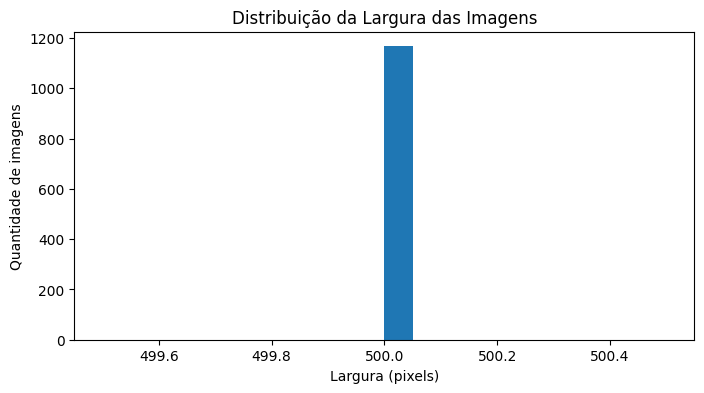

In [30]:
# Histograma da Largura
plt.figure(figsize=(8,4))
plt.hist(df['width'], bins=20)
plt.xlabel('Largura (pixels)')
plt.ylabel('Quantidade de imagens')
plt.title('Distribuição da Largura das Imagens')
plt.show()

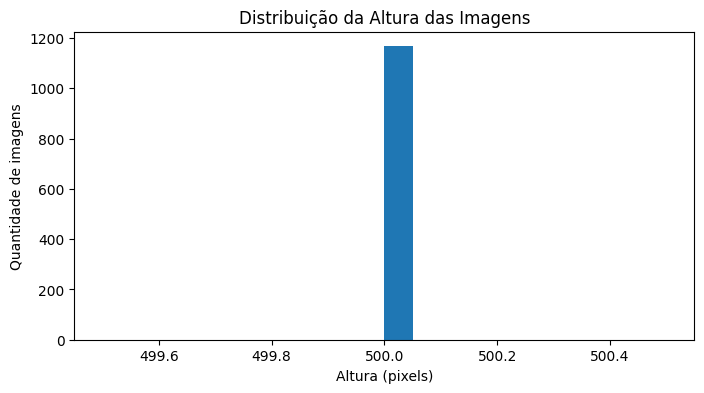

In [31]:
# Histograma da altura
plt.figure(figsize=(8,4))
plt.hist(df['height'], bins=20)
plt.xlabel('Altura (pixels)')
plt.ylabel('Quantidade de imagens')
plt.title('Distribuição da Altura das Imagens')
plt.show()

In [32]:
dimensoes = (
    df.groupby(['width', 'height'])
      .size()
      .reset_index(name='quantidade')
)

print(dimensoes)

   width  height  quantidade
0    500     500        1167


In [33]:
print(df.columns)

Index(['image_path', 'corrupted', 'image_hash', 'image_format', 'width',
       'height', 'channels', 'label'],
      dtype='object')


In [34]:
#Quantidade de informações nulas
df.isnull().sum()

,0
image_path,0
corrupted,0
image_hash,0
image_format,0
width,0
height,0
channels,0
label,0


### Qualidade das Imagens

In [35]:
#Total de imagens corrompidas

df['corrupted'].sum()

np.int64(0)

In [36]:
#Quantidade de imagens corrompidas e não corrompidas

df['corrupted'].value_counts()

,count
corrupted,
False,1167


### Distribuição das Classes

In [37]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 5]

In [38]:
from pathlib import Path
import pandas as pd

# Caminho apontando para a pasta que você mostrou na imagem
pastas = {
    "Treinamento": "/content/drive/MyDrive/bean-leaf-lesions-classification",
    "Validação": "/content/drive/MyDrive/bean-leaf-lesions-classification/val",
    "Teste": "/content/drive/MyDrive/bean-leaf-lesions-classification/test"
}


# Extensões de imagem comuns
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

data = []

# Varre todos os arquivos dentro da pasta archive
for split_name, folder_path_str in pastas.items():
    folder_path = Path(folder_path_str)
    for file_path in folder_path.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
            # Captura o caminho relativo a partir do diretório base (por exemplo, train, val, test)
            # A estrutura esperada agora é: base_folder/classe/imagem.jpg
            relative_to_base = file_path.relative_to(folder_path)

            # A label é o nome da pasta da classe
            label = relative_to_base.parent.name

            data.append({"Split": split_name, "Classe": label})

# Criar o DataFrame principal
df_images = pd.DataFrame(data)

if df_images.empty:
    print("Nenhuma imagem encontrada. Verifique os caminhos e a estrutura das pastas.")
else:
    print(f"Total de imagens encontradas: {len(df_images)}")

Total de imagens encontradas: 1454


In [39]:
# Agrupa por classe e split (se houver) para contar
if df_images['Split'].nunique() > 1:
    df_dist = df_images.groupby(['Split', 'Classe']).size().reset_index(name='Quantidade')
    df_dist['Porcentagem (%)'] = (df_dist['Quantidade'] / df_dist.groupby('Split')['Quantidade'].transform('sum')) * 100
else:
    df_dist = df_images.groupby('Classe').size().reset_index(name='Quantidade')
    df_dist['Porcentagem (%)'] = (df_dist['Quantidade'] / df_dist['Quantidade'].sum()) * 100

# Exibir a tabela formatada
print("\n         Tabela de Distribuição de Classes")
print(df_dist.to_string(index=False, formatters={'Porcentagem (%)': '{:.2f}%'.format}))


         Tabela de Distribuição de Classes
      Split            Classe  Quantidade Porcentagem (%)
      Teste angular_leaf_spot          49          31.82%
      Teste         bean_rust          55          35.71%
      Teste           healthy          50          32.47%
Treinamento angular_leaf_spot         389          33.33%
Treinamento         bean_rust         393          33.68%
Treinamento           healthy         385          32.99%
  Validação angular_leaf_spot          44          33.08%
  Validação         bean_rust          45          33.83%
  Validação           healthy          44          33.08%


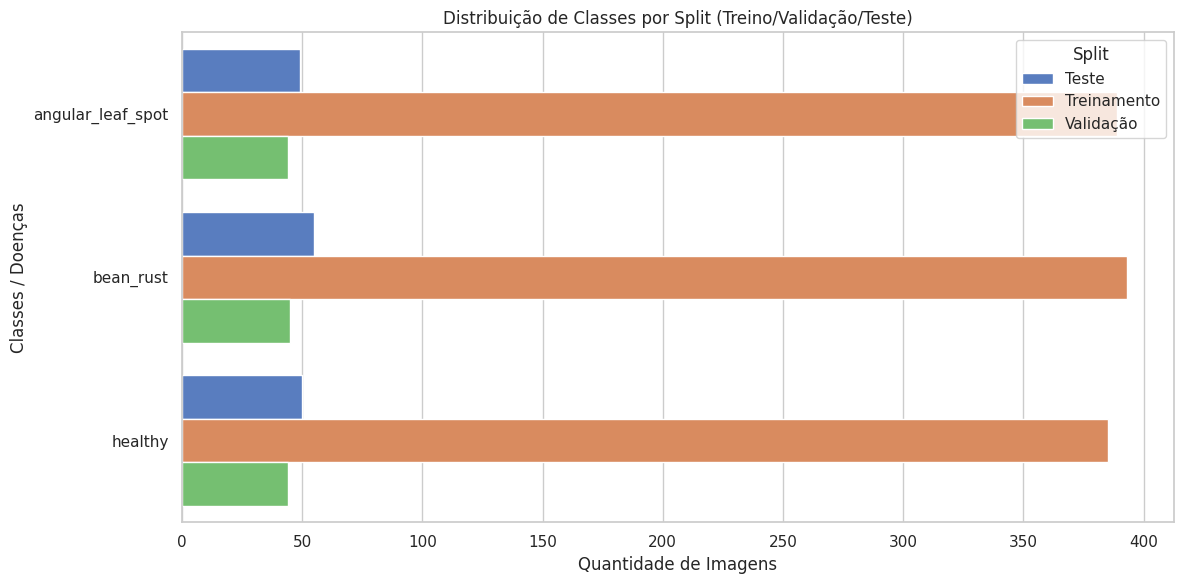

In [40]:
# Plotar o gráfico dependendo da estrutura encontrada
plt.figure(figsize=(12, 6))

if df_images['Split'].nunique() > 1:
    # Gráfico comparativo se houver divisões de treino/validação/teste
    sns.barplot(x='Quantidade', y='Classe', hue='Split', data=df_dist, palette='muted')
    plt.title('Distribuição de Classes por Split (Treino/Validação/Teste)')
else:
    # Gráfico simples
    sns.barplot(x='Quantidade', y='Classe', data=df_dist.sort_values('Quantidade', ascending=False), palette='viridis')
    plt.title('Distribuição Geral de Classes - Lesões de Folhas de Feijão')

plt.xlabel('Quantidade de Imagens')
plt.ylabel('Classes / Doenças')
plt.tight_layout()
plt.show()

## Insights

- As três classes (angular_leaf_spot, bean_rust e healthy) estão distribuídas de forma praticamente idêntica, representando aproximadamente entre 31% e 34% do dataset cada uma. Não é preciso se preocupar com o balanceamento de dados, o modelo tem a quantidade de exemplos necessária para saber o que é uma folha saudável e o que é cada tipo de doença.

-  A Acurácia nesse projeto vai ser uma métrica extremamente confiável devido a natureza balanceada apresentada nesse dataset.



# Resumo

## O que o código faz (Passo a Passo):
- Configuração do Ambiente: Importa as bibliotecas necessárias para manipulação de arquivos (pathlib), modelagem de dados (pandas) e plotagem gráfica (matplotlib e seaborn), definindo um tema visual padronizado.

- Mapeamento Dinâmico de Arquivos: Varre a pasta alvo (archive) filtrando apenas extensões de imagem válidas (.jpg, .jpeg, .png, .bmp). Ele analisa a estrutura de pastas para extrair automaticamente o Split (Treino/Validação/Teste) e a Classe (tipo de doença ou folha saudável), organizando tudo em um DataFrame do Pandas.

- Análise Estatística da Distribuição: Agrupa os dados para calcular a quantidade absoluta de imagens e a porcentagem que cada classe representa dentro de seu respectivo split, exibindo uma tabela formatada no console.

- Visualização Gráfica: Gera um gráfico de barras horizontal comparativo utilizando o seaborn. O gráfico ilustra visualmente a distribuição das classes por split, facilitando a verificação de um possível desbalanceamento de dados.

### Duplicatas

In [41]:
import hashlib
import os
from pathlib import Path
import pandas as pd

# Caminho apontando para a pasta que você mostrou na imagem
pastas = {
     "/content/drive/MyDrive/bean-leaf-lesions-classification"
    }


In [42]:
# Buscar arquivos CSV ou JSON no diretório
metadata_files = []
for path_str in pastas:
    folder_path = Path(path_str)
    metadata_files.extend(list(folder_path.rglob("*.csv")))
    metadata_files.extend(list(folder_path.rglob("*.json")))

if metadata_files:
    print(f" Encontrado(s) {len(metadata_files)} arquivo(s) de metadados:")
    for meta_path in metadata_files:
        print(f"\n--- Analisando: {meta_path.name} ---")
        if meta_path.suffix == '.csv':
            df_meta = pd.read_csv(meta_path)
        else:
            df_meta = pd.read_json(meta_path)

        # Total de linhas vs Linhas únicas
        total_rows = len(df_meta)
        duplicated_rows = df_meta.duplicated().sum()

        print(f"Total de registros: {total_rows}")
        print(f"Linhas exatamente duplicadas: {duplicated_rows}")

        if duplicated_rows > 0:
            print(" Exemplo de linhas duplicadas:")
            print(df_meta[df_meta.duplicated(keep=False)].head())
else:
    print(" Nenhum arquivo CSV/JSON de metadados encontrado na pasta. Prosseguindo para a verificação das imagens...")

 Encontrado(s) 3 arquivo(s) de metadados:

--- Analisando: train.csv ---
Total de registros: 1034
Linhas exatamente duplicadas: 0

--- Analisando: val.csv ---
Total de registros: 133
Linhas exatamente duplicadas: 0

--- Analisando: test.csv ---
Total de registros: 154
Linhas exatamente duplicadas: 0


In [43]:
def calculate_md5(file_path, chunk_size=8192):
    """Calcula o hash MD5 de um arquivo lendo em partes (eficiente em memória)."""
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)
    return hasher.hexdigest()
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
image_records = []

print(" Mapeando e gerando hashes de todas as imagens...")

for path_str in pastas:
    base_folder_path = Path(path_str)
    for file_path in base_folder_path.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
            # Determine the relative path to extract split and label
            # We need to reconstruct the relative path from the *first* folder after the base_folder_path
            # For example, if base_folder_path is 'train' and file_path is 'train/healthy/image.jpg'
            # relative_parts should start from 'healthy'

            relative_to_base = file_path.relative_to(base_folder_path)
            parts = relative_to_base.parts

            # Assuming structure: base_folder_path/classe/imagem.jpg
            # If there's only one part, it means it's directly in the base_folder_path, which is unlikely for class labels
            if len(parts) >= 1:
                label = parts[0] # The first subfolder is typically the class
            else:
                label = "unknown" # Fallback if no class folder is found

            # In this context, 'pastas' holds only training data, so 'split' can be hardcoded or inferred if structure allows.
            # For now, let's assume if it's in 'train', split is 'Treinamento'.
            split = "Treinamento" # Adjust if 'pastas' can contain other splits

            # Generates the MD5 hash of the image content
            file_hash = calculate_md5(file_path)

            image_records.append({
                "filename": file_path.name,
                "path": str(file_path),
                "split": split,
                "classe": label,
                "hash_md5": file_hash
            })

df_hashes = pd.DataFrame(image_records)
print(f" Concluído! {len(df_hashes)} imagens processadas.")

 Mapeando e gerando hashes de todas as imagens...
 Concluído! 1167 imagens processadas.


In [44]:
# Identificar hashes que aparecem mais de uma vez
duplicate_hashes = df_hashes[df_hashes.duplicated(subset=['hash_md5'], keep=False)]

if duplicate_hashes.empty:
    print("NENHUMA DUPLICATA ENCONTRADA! O dataset está 100% limpo quanto a conteúdos idênticos.")
else:
    total_duplicadas = duplicate_hashes['hash_md5'].nunique()
    print(f"Foram encontradas imagens duplicadas associadas a {total_duplicadas} hashes diferentes.\n")

    # 1. Checar se há VAZAMENTO DE DADOS (Data Leakage) entre Train e Val
    leakage_df = duplicate_hashes.groupby('hash_md5')['split'].nunique()
    hashes_vazados = leakage_df[leakage_df > 1].index

    if len(hashes_vazados) > 0:
        print(f"ALERTA CRÍTICO DE DATA LEAKAGE!")
        print(f"Existem {len(hashes_vazados)} imagem(ns) idêntica(s) presentes TANTO no Treino QUANTO na Validação.\n")
        print("Exemplos de imagens com vazamento:")
        display(duplicate_hashes[duplicate_hashes['hash_md5'].isin(hashes_vazados)][['filename', 'split', 'classe', 'hash_md5']].head(10))
    else:
        print("Sem Data Leakage: As duplicatas existem, mas não estão cruzando a fronteira de treino/validação.")

    # 2. Exibir tabela resumo de todas as duplicatas
    print("\n--- Tabela Completa de Arquivos Duplicados ---")
    display(duplicate_hashes.sort_values(by='hash_md5')[['filename', 'split', 'classe', 'hash_md5']])

NENHUMA DUPLICATA ENCONTRADA! O dataset está 100% limpo quanto a conteúdos idênticos.


### Informações complementares
Elaborar uma apresentação para mostrar os resultados.

Apresentar o dataset de forma detalhada.

Verifique quais itens em Informações esperadas podem ser aplicados no dataset.

### ATIVIDADE-04-ETAPA-02

#### Objetivo: Apresentar métodos da literatura e propor ideias para métodos próprios.



### Métodos da literatura

#### Notebooks executados

https://www.kaggle.com/code/akhilchibber/bean-leaf-lesions-classification#The-Dataset

 https://www.kaggle.com/code/marquis03/resnet-18-bean-leaf-lesions-classification

### Métodos próprios

#### Apresentar ideias que podem melhorar os métodos encontrados e testados da literatura.

- O notebook analisado não realizou a separação das imagens para teste, portanto sugerimos a separação de uma parte das imagens de treinamento como melhoria;

- O notebook não realizou a análise exploratória dos dados, portanto, a imagem corrompida não foi excluída do dataset;



#### Ideias para melhorar uma técnica

Otimização de Hiperparâmetros - alterar ou reduzir os hiperparâmetros.

Elaborar uma nova arquitetura mais leve para que o treino e o teste sejam rápidos.

Reduzir número de imagens no treinamento e manter o desempenho.

### Informações complementares

Elaborar uma apresentação para mostrar os métodos da literatura e próprios.

### ATIVIDADE-04-ETAPA-03

#### Objetivo

Apresentar métodos da literatura e métodos próprios.

### Metodologia

Explicação: Este código importa as bibliotecas necessárias para treinar e avaliar um modelo de visão computacional usando o PyTorch e o modelo pré-treinado ResNet-50. Ele inclui bibliotecas para:
- Processamento de dados com NumPy, Pandas, e Scikit-learn.
- Manipulação e transformação de imagens com OpenCV e torchvision.
- Construção e treinamento de redes neurais profundas com PyTorch.
- Visualização de resultados com Matplotlib e Seaborn.
- Avaliação de desempenho com métricas como accuracy, classification report, e confusion matrix.

In [45]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import warnings
warnings.filterwarnings("ignore")

import os

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

import cv2

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from copy import deepcopy

# Hiperparâmetros de treinamento


Explicação: Hiperparâmetros são variáveis ajustáveis definidas pelo usuário que controlam o comportamento e o desempenho de um modelo de aprendizado de máquina. Eles não são aprendidos pelo modelo durante o treinamento, mas são escolhidos antes do processo de treinamento para otimizar os resultados. À seguir são descritos os hiperparâmetros definidos na sequência:

- EPOCHS: Número de vezes que o modelo passará por todo o conjunto de dados de treinamento. Mais epochs podem resultar em um modelo melhor treinado, mas também aumentam o risco de overfitting.

- LR (Learning Rate): Taxa de aprendizado, que controla o tamanho dos ajustes que o modelo faz nos pesos a cada passo de otimização. Um valor alto acelera o treinamento, mas pode dificultar a convergência para o mínimo ideal.

- GAMMA: Fator de redução da taxa de aprendizado. Usado com técnicas de agendamento, como o StepLR, para reduzir o valor de LR após certos intervalos de tempo.

- STEP: Número de epochs após o qual a taxa de aprendizado será reduzida. Combinado com GAMMA. Neste caso, combinado com GAMMA, ajusta a taxa de aprendizado a cada 7 epochs.

- IMG_SIZE: Tamanho das imagens de entrada (altura e largura) que o modelo irá processar. Neste caso, as imagens serão redimensionadas para 224x224 pixels.

- BATCH = 25: Tamanho do batch, ou seja, o número de amostras de imagens processadas antes de atualizar os pesos do modelo. Batches maiores aceleram o treinamento, mas exigem mais memória.

- OUT_SIZE: Número de classes que o modelo deve prever, neste caso, 3 categorias ou rótulos de saída.

Resumo dos hiperparâmetros

EPOCHS: Define quantas vezes o modelo percorre todo o conjunto de treinamento.
LR (Learning Rate): Controla o tamanho dos ajustes realizados nos pesos durante o treinamento.
GAMMA: Define o fator pelo qual a taxa de aprendizado será reduzida.
STEP: Determina a frequência (em número de épocas) com que a taxa de aprendizado será reduzida.
IMG_SIZE: Define a resolução das imagens utilizadas como entrada da rede neural.
BATCH_SIZE: Indica quantas imagens são processadas antes de cada atualização dos pesos.
OUT_SIZE: Define o número de classes que o modelo deve classificar.

In [ ]:
EPOCHS = 20
LR = 0.1
GAMMA = 0.1
STEP = 7
IMG_SIZE = 224
BATCH = 25
OUT_SIZE = 3

# Pipeline de Pré-processamento do Dataset

Explicação: A classe Pipeline é usada para carregar, pré-processar e transformar imagens de um conjunto de dados. Quando solicitada, ela recupera uma imagem pelo caminho, aplica as transformações (como redimensionamento ou normalização), e retorna a imagem transformada junto com seu rótulo correspondente. Isso facilita o treinamento de redes neurais, pois o PyTorch pode usar essa classe para carregar as imagens de forma eficiente.

In [46]:


class Pipeline(Dataset):
    def __init__(self, root_dir, csv_file=None, subset_dir="train", transform=None):
        super(Pipeline, self).__init__()
        self.root_dir = root_dir
        self.transform = transform
        self.data = []


        self.target_dir = os.path.join(root_dir, subset_dir)

        # Identifica as classes pelas subpastas existentes
        self.classes = sorted([d for d in os.listdir(self.target_dir) if os.path.isdir(os.path.join(self.target_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # 1. Leitura via CSV (para Train e Val)
        if csv_file is not None:
            csv_path = os.path.join(root_dir, csv_file)
            df = pd.read_csv(csv_path)

            for _, row in df.iterrows():
                img_name = row["image:FILE"]

                # Procura o arquivo na pasta da respectiva classe
                for cls_name in self.classes:
                    img_path = os.path.join(self.target_dir, cls_name, img_name)
                    if os.path.isfile(img_path):
                        self.data.append((img_path, self.class_to_idx[cls_name]))
                        break

        # 2. Leitura via Pasta (para a pasta Test criada no sorteio das 154 imagens)
        else:
            for cls_name in self.classes:
                cls_dir = os.path.join(self.target_dir, cls_name)
                for img_name in os.listdir(cls_dir):
                    img_path = os.path.join(cls_dir, img_name)
                    if os.path.isfile(img_path):
                        self.data.append((img_path, self.class_to_idx[cls_name]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, x):
        img_path, label = self.data[x]

        # Leitura com OpenCV
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        return img, label

# Configuracão do pré-processamento e definição do pipeline de transformação de imagem

Explicação: Este código configura um pipeline de transformação de imagens e divide um conjunto de dados em conjuntos de treinamento, validação e teste, além de preparar os DataLoaders para facilitar o carregamento dos dados durante o treinamento de um modelo.

In [47]:
from torchvision import transforms
from torch.utils.data import DataLoader

root_dir = '/content/drive/MyDrive/bean-leaf-lesions-classification'

# Transformações para treinamento
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transformações para validação e teste
val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#DATASETS

train_dataset = Pipeline(
    root_dir=root_dir,
    subset_dir='train',
    transform=train_transform
)

val_dataset = Pipeline(
    root_dir=root_dir,
    subset_dir='val',
    transform=val_test_transform
)

test_dataset = Pipeline(
    root_dir=root_dir,
    subset_dir='test',
    transform=val_test_transform
)

#QUANTIDADE DE IMAGENS

print(f"Treino: {len(train_dataset)} imagens")
print(f"Validação: {len(val_dataset)} imagens")
print(f"Teste: {len(test_dataset)} imagens")

#DATALOADERS

BATCH_SIZE = 25

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Pipeline configurado com sucesso!")

Treino: 880 imagens
Validação: 133 imagens
Teste: 154 imagens
Pipeline configurado com sucesso!


#  Definindo dispositivo de treinamento com ferramentas de treinamento

Explicação: O código carrega um modelo ResNet-50 pré-treinado, adapta sua camada de saída para um novo número de classes, define uma nova classe para a rede, e prepara o modelo para treinamento em um dispositivo (GPU ou CPU). Ele também configura a função de perda, o otimizador e o agendador de taxa de aprendizado para o processo de treinamento.

In [ ]:
'''
import torch
import torch.nn as nn

from torchvision.models import resnet50, ResNet50_Weights
'''

'\nimport torch\nimport torch.nn as nn\n\nfrom torchvision.models import resnet50, ResNet50_Weights\n'

In [ ]:
'''
resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
OUT_SIZE = 3
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, OUT_SIZE)



class ResNet50(nn.Module):
    def __init__(self, model):
        super(ResNet50, self).__init__()
        self.model = model

    def forward(self, x):
        return nn.functional.softmax(self.model(x), dim=1)


device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

model = ResNet50(resnet)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP, gamma=GAMMA)
'''

'\nresnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)\nOUT_SIZE = 3\nnum_ftrs = resnet.fc.in_features\nresnet.fc = nn.Linear(num_ftrs, OUT_SIZE)\n\n\n\nclass ResNet50(nn.Module):\n    def __init__(self, model):\n        super(ResNet50, self).__init__()\n        self.model = model\n\n    def forward(self, x):\n        return nn.functional.softmax(self.model(x), dim=1)\n\n\ndevice = "cuda" if torch.cuda.is_available() else "cpu"\nprint(device)\n\nmodel = ResNet50(resnet)\nmodel = model.to(device)\n\ncriterion = nn.CrossEntropyLoss()\noptimizer = torch.optim.SGD(model.parameters(), lr=LR)\nscheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP, gamma=GAMMA)\n'

# Loop de Treinamento

Explicação: Este código realiza o treinamento de um modelo de aprendizado de máquina em um loop de épocas, avaliando o desempenho tanto no conjunto de treinamento quanto no de validação.

In [ ]:
'''log = {
    "train_loss": [], "train_acc": [],
    "val_loss": [],   "val_acc": []
}

best_acc = 0.0
best_model_wts = deepcopy(model.state_dict())

for epoch in range(EPOCHS):

    # Treino
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = running_corrects / total

    # Validação
    model.eval()
    val_running_loss = 0.0
    val_corrects = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels).item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_corrects / val_total

    # Reduz a taxa de aprendizado a cada STEP épocas
    scheduler.step()

    # Registra o log da época
    log["train_loss"].append(train_loss)
    log["train_acc"].append(train_acc)
    log["val_loss"].append(val_loss)
    log["val_acc"].append(val_acc)

    # Guarda os pesos do melhor modelo (maior acurácia de validação)
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = deepcopy(model.state_dict())
        torch.save(best_model_wts, "melhor_modelo.pth")

    print(
        f"Época {epoch+1:02d}/{EPOCHS} | "
        f"LR: {optimizer.param_groups[0]['lr']:.5f} | "
        f"Treino  -> loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
        f"Validação -> loss: {val_loss:.4f}  acc: {val_acc:.4f}"
    )

# Restaura os melhores pesos encontrados
model.load_state_dict(best_model_wts)
print(f"\nTreinamento concluído. Melhor acurácia de validação: {best_acc:.4f}")
'''

'log = {\n    "train_loss": [], "train_acc": [],\n    "val_loss": [],   "val_acc": []\n}\n\nbest_acc = 0.0\nbest_model_wts = deepcopy(model.state_dict())\n\nfor epoch in range(EPOCHS):\n\n    # Treino\n    model.train()\n    running_loss = 0.0\n    running_corrects = 0\n    total = 0\n\n    for images, labels in train_loader:\n        images = images.to(device)\n        labels = labels.to(device)\n\n        optimizer.zero_grad()\n\n        outputs = model(images)\n        loss = criterion(outputs, labels)\n\n        loss.backward()\n        optimizer.step()\n\n        running_loss += loss.item() * images.size(0)\n        _, preds = torch.max(outputs, 1)\n        running_corrects += torch.sum(preds == labels).item()\n        total += labels.size(0)\n\n    train_loss = running_loss / total\n    train_acc = running_corrects / total\n\n    # Validação\n    model.eval()\n    val_running_loss = 0.0\n    val_corrects = 0\n    val_total = 0\n\n    with torch.no_grad():\n        for images, lab

### Resultados

# Visualização do log de Desempenho do Treinamento

Explicação: Este código é responsável por criar gráficos que visualizam a perda (loss) e a acurácia do modelo durante o treinamento e a validação.

In [ ]:
'''plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(log['train_acc'], label='Acurácia de Treino')
plt.plot(log['val_acc'], label='Acurácia de Validação')
plt.title('Acurácia por Época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(log['train_loss'], label='Perda de Treino')
plt.plot(log['val_loss'], label='Perda de Validação')
plt.title('Perda (Loss) por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
'''

"plt.figure(figsize=(12, 5))\n\nplt.subplot(1, 2, 1)\nplt.plot(log['train_acc'], label='Acurácia de Treino')\nplt.plot(log['val_acc'], label='Acurácia de Validação')\nplt.title('Acurácia por Época')\nplt.xlabel('Época')\nplt.ylabel('Acurácia')\nplt.legend()\nplt.grid(True)\n\nplt.subplot(1, 2, 2)\nplt.plot(log['train_loss'], label='Perda de Treino')\nplt.plot(log['val_loss'], label='Perda de Validação')\nplt.title('Perda (Loss) por Época')\nplt.xlabel('Época')\nplt.ylabel('Loss')\nplt.legend()\nplt.grid(True)\n\nplt.tight_layout()\nplt.show()\n"

In [ ]:
'''classes = train_dataset.classes   # ['angular_leaf_spot', 'bean_rust', 'healthy']


def predict(image_path, model=model, transform=val_test_transform, device=device):
    """
    Carrega uma imagem do disco, aplica o mesmo pré-processamento usado na
    validação e retorna o índice da classe prevista e a probabilidade associada.
    """
    img = cv2.imread(image_path)

    if img is None:
        raise FileNotFoundError(f"Não foi possível ler a imagem: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # (3, 224, 224) -> (1, 3, 224, 224), pois o modelo espera um batch
    tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probs = model(tensor)              # o forward já aplica softmax
        prob, idx = torch.max(probs, 1)

    return idx.item(), prob.item()


# Desempenho do Conjunto de Teste
model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

print(f"Acurácia no conjunto de teste: {accuracy_score(y_true, y_pred):.4f}\n")

# Exemplo de uso da função predict
caminho_exemplo, label_real = test_dataset.data[random.randint(0,154)]
idx, prob = predict(caminho_exemplo)

print(f"Arquivo:         {os.path.basename(caminho_exemplo)}")
print(f"Classe prevista: {classes[idx]} ({prob*100:.2f}%)")
print(f"Classe real:     {classes[label_real]}")
'''

'classes = train_dataset.classes   # [\'angular_leaf_spot\', \'bean_rust\', \'healthy\']\n\n\ndef predict(image_path, model=model, transform=val_test_transform, device=device):\n    """\n    Carrega uma imagem do disco, aplica o mesmo pré-processamento usado na\n    validação e retorna o índice da classe prevista e a probabilidade associada.\n    """\n    img = cv2.imread(image_path)\n\n    if img is None:\n        raise FileNotFoundError(f"Não foi possível ler a imagem: {image_path}")\n\n    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\n\n    # (3, 224, 224) -> (1, 3, 224, 224), pois o modelo espera um batch\n    tensor = transform(img).unsqueeze(0).to(device)\n\n    model.eval()\n    with torch.no_grad():\n        probs = model(tensor)              # o forward já aplica softmax\n        prob, idx = torch.max(probs, 1)\n\n    return idx.item(), prob.item()\n\n\n# Desempenho do Conjunto de Teste\nmodel.eval()\ny_true, y_pred, y_prob = [], [], []\n\nwith torch.no_grad():\n    for images, 

# Predição, desempenho do modelo de teste e avaliação

Explicação: A função predict carrega e processa uma imagem, a transforma em um formato compatível com o modelo, e então utiliza o modelo para prever a classe da imagem. Ela retorna tanto o índice da classe prevista quanto a probabilidade dessa classe. Isso permite avaliar com que certeza o modelo fez a previsão.

In [ ]:
'''#como a predição foi realizada nas células anteriores, geraremos aqui
#o relatório das métricas de classificação mais conhecidas usando o sckitlearn
#(acurácia, f1-score, precisão e recall)

classes = train_dataset.classes

print("\nRelatório de Classificação no Conjunto de Teste:")
print(classification_report(y_true, y_pred, target_names=classes))
'''

'#como a predição foi realizada nas células anteriores, geraremos aqui\n#o relatório das métricas de classificação mais conhecidas usando o sckitlearn\n#(acurácia, f1-score, precisão e recall)\n\nclasses = train_dataset.classes\n\nprint("\nRelatório de Classificação no Conjunto de Teste:")\nprint(classification_report(y_true, y_pred, target_names=classes))\n'

# Matriz de confusão

Explicação: Este código avalia um modelo de classificação em um conjunto de teste, armazenando rótulos verdadeiros e previsões. Ele gera um relatório de classificação e visualiza a matriz de confusão, mostrando o desempenho do modelo em termos de acurácia e outras métricas.

In [ ]:
'''#matriz
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão do Conjunto de Teste')
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.show()
'''

"#matriz\ncm = confusion_matrix(y_true, y_pred)\nplt.figure(figsize=(8, 6))\nsns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)\nplt.title('Matriz de Confusão do Conjunto de Teste')\nplt.xlabel('Previsão')\nplt.ylabel('Verdadeiro')\nplt.show()\n"

# Inspeção Visual

Explicação: O código à seguir visualiza as previsões de um modelo em um conjunto de teste, mostrando 9 imagens em uma grade. Cada imagem é acompanhada de sua previsão, a probabilidade da previsão e o rótulo verdadeiro. Isso ajuda a entender como o modelo está se comportando em relação às classes reais.

### Conclusões

## Treinamento utilizando o modelo Resnet18


###Instalando bibliotecas


In [48]:
!pip install torch torchvision

In [49]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torchvision.models as models

from torchvision import datasets, models
from torch.utils.data import DataLoader, random_split

### Preparando as imagens

In [50]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Carregando dataset

In [51]:
dataset_path = "/content/drive/MyDrive/bean-leaf-lesions-classification"

In [52]:
dataset_path = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

In [53]:
print(dataset_path.classes)
print(dataset_path.class_to_idx)
print("Quantidade de imagens:", len(dataset_path))

['test', 'train', 'val']
{'test': 0, 'train': 1, 'val': 2}
Quantidade de imagens: 1167


In [54]:
train_size = int(0.70 * len(dataset_path))
val_size = int(0.15 * len(dataset_path))
test_size = len(dataset_path) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset_path,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [55]:
print("Treino:", len(train_dataset))
print("Validação:", len(val_dataset))
print("Teste:", len(test_dataset))

Treino: 816
Validação: 175
Teste: 176


### Criando os "loaders"

In [56]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

### Carregando o ResNet18

In [57]:
import torch
import torchvision
from torchvision import models

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


In [58]:
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


In [59]:
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [60]:
num_classes = len(dataset_path.classes)

print(num_classes)

3


In [61]:
# Mudando o número de classes do resnet18 para 3 classes

model.fc = torch.nn.Linear(
    model.fc.in_features,
    num_classes
)

In [62]:
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [64]:
model = model.to(device)

## Pre-processamento dos dados para a Resnet18

In [65]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import warnings
warnings.filterwarnings("ignore")

import os

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

import cv2

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from copy import deepcopy

In [66]:
EPOCHS = 20
LR = 0.1
GAMMA = 0.1
STEP = 7
IMG_SIZE = 224
BATCH = 25
OUT_SIZE = 3

## Pipeline de pré-processamento para o Resnet18

In [67]:

class Pipeline(Dataset):
    def __init__(self, root_dir, csv_file=None, subset_dir="train", transform=None):
        super(Pipeline, self).__init__()
        self.root_dir = root_dir
        self.transform = transform
        self.data = []


        self.target_dir = os.path.join(root_dir, subset_dir)

        # Identifica as classes pelas subpastas existentes
        self.classes = sorted([d for d in os.listdir(self.target_dir) if os.path.isdir(os.path.join(self.target_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # 1. Leitura via CSV (para Train e Val)
        if csv_file is not None:
            csv_path = os.path.join(root_dir, csv_file)
            df = pd.read_csv(csv_path)

            for _, row in df.iterrows():
                img_name = row["image:FILE"]

                # Procura o arquivo na pasta da respectiva classe
                for cls_name in self.classes:
                    img_path = os.path.join(self.target_dir, cls_name, img_name)
                    if os.path.isfile(img_path):
                        self.data.append((img_path, self.class_to_idx[cls_name]))
                        break

        # 2. Leitura via Pasta (para a pasta Test criada no sorteio das 154 imagens)
        else:
            for cls_name in self.classes:
                cls_dir = os.path.join(self.target_dir, cls_name)
                for img_name in os.listdir(cls_dir):
                    img_path = os.path.join(cls_dir, img_name)
                    if os.path.isfile(img_path):
                        self.data.append((img_path, self.class_to_idx[cls_name]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, x):
        img_path, label = self.data[x]

        # Leitura com OpenCV
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        return img, label

In [68]:
from torchvision import transforms
from torch.utils.data import DataLoader

root_dir = '/content/drive/MyDrive/bean-leaf-lesions-classification'

# Transformações para treinamento
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transformações para validação e teste
val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#DATASETS

train_dataset = Pipeline(
    root_dir=root_dir,
    subset_dir='train',
    transform=train_transform
)

val_dataset = Pipeline(
    root_dir=root_dir,
    subset_dir='val',
    transform=val_test_transform
)

test_dataset = Pipeline(
    root_dir=root_dir,
    subset_dir='test',
    transform=val_test_transform
)

#QUANTIDADE DE IMAGENS

print(f"Treino: {len(train_dataset)} imagens")
print(f"Validação: {len(val_dataset)} imagens")
print(f"Teste: {len(test_dataset)} imagens")

#DATALOADERS

BATCH_SIZE = 25

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Pipeline configurado com sucesso!")

Treino: 880 imagens
Validação: 133 imagens
Teste: 154 imagens
Pipeline configurado com sucesso!


## Carregando o modelo Resnet18

In [69]:
import torch
import torch.nn as nn
import torchvision.models as models

# Carrega a ResNet18
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

OUT_SIZE = 3
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, OUT_SIZE)



class ResNet18(nn.Module):
    def __init__(self, model):
        super(ResNet18, self).__init__()
        self.model = model

    def forward(self, x):
        return nn.functional.softmax(self.model(x), dim=1)


device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

model = ResNet18(resnet)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=STEP,
    gamma=GAMMA
)

cuda


## Loop de treinamento para Resnet18

In [70]:
log = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": []
}

best_acc = 0.0
best_model_wts = deepcopy(model.state_dict())

for epoch in range(EPOCHS):

    # =========================
    # TREINAMENTO
    # =========================
    model.train()

    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)

        running_corrects += torch.sum(
            preds == labels
        ).item()

        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = running_corrects / total

    # =========================
    # VALIDAÇÃO
    # =========================
    model.eval()

    val_running_loss = 0.0
    val_corrects = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            val_corrects += torch.sum(
                preds == labels
            ).item()

            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_corrects / val_total

    # Atualiza o learning rate
    scheduler.step()

    # =========================
    # LOG
    # =========================
    log["train_loss"].append(train_loss)
    log["train_acc"].append(train_acc)
    log["val_loss"].append(val_loss)
    log["val_acc"].append(val_acc)

    # =========================
    # SALVA MELHOR MODELO
    # =========================
    if val_acc > best_acc:

        best_acc = val_acc

        best_model_wts = deepcopy(
            model.state_dict()
        )

        torch.save(
            best_model_wts,
            "melhor_modelo.pth"
        )

    print(
        f"Época {epoch+1:02d}/{EPOCHS} | "
        f"LR: {optimizer.param_groups[0]['lr']:.5f} | "
        f"Treino -> "
        f"loss: {train_loss:.4f} "
        f"acc: {train_acc:.4f} | "
        f"Validação -> "
        f"loss: {val_loss:.4f} "
        f"acc: {val_acc:.4f}"
    )

# Restaura os melhores pesos
model.load_state_dict(best_model_wts)

print(
    f"\nTreinamento concluído. "
    f"Melhor acurácia de validação: {best_acc:.4f}"
)

Época 01/20 | LR: 0.10000 | Treino -> loss: 0.8286 acc: 0.7114 | Validação -> loss: 1.0005 acc: 0.5188
Época 02/20 | LR: 0.10000 | Treino -> loss: 0.6639 acc: 0.8818 | Validação -> loss: 0.7163 acc: 0.8195
Época 03/20 | LR: 0.10000 | Treino -> loss: 0.6247 acc: 0.9239 | Validação -> loss: 0.6141 acc: 0.9323
Época 04/20 | LR: 0.10000 | Treino -> loss: 0.6017 acc: 0.9511 | Validação -> loss: 0.7184 acc: 0.8271
Época 05/20 | LR: 0.10000 | Treino -> loss: 0.5876 acc: 0.9659 | Validação -> loss: 0.6434 acc: 0.9023
Época 06/20 | LR: 0.10000 | Treino -> loss: 0.5802 acc: 0.9739 | Validação -> loss: 0.6316 acc: 0.9248
Época 07/20 | LR: 0.01000 | Treino -> loss: 0.5795 acc: 0.9716 | Validação -> loss: 0.5849 acc: 0.9624
Época 08/20 | LR: 0.01000 | Treino -> loss: 0.5738 acc: 0.9784 | Validação -> loss: 0.5766 acc: 0.9774
Época 09/20 | LR: 0.01000 | Treino -> loss: 0.5701 acc: 0.9830 | Validação -> loss: 0.5674 acc: 0.9774
Época 10/20 | LR: 0.01000 | Treino -> loss: 0.5733 acc: 0.9784 | Validaçã

## Visualização do log de Desempenho do Treinamento Resnet18

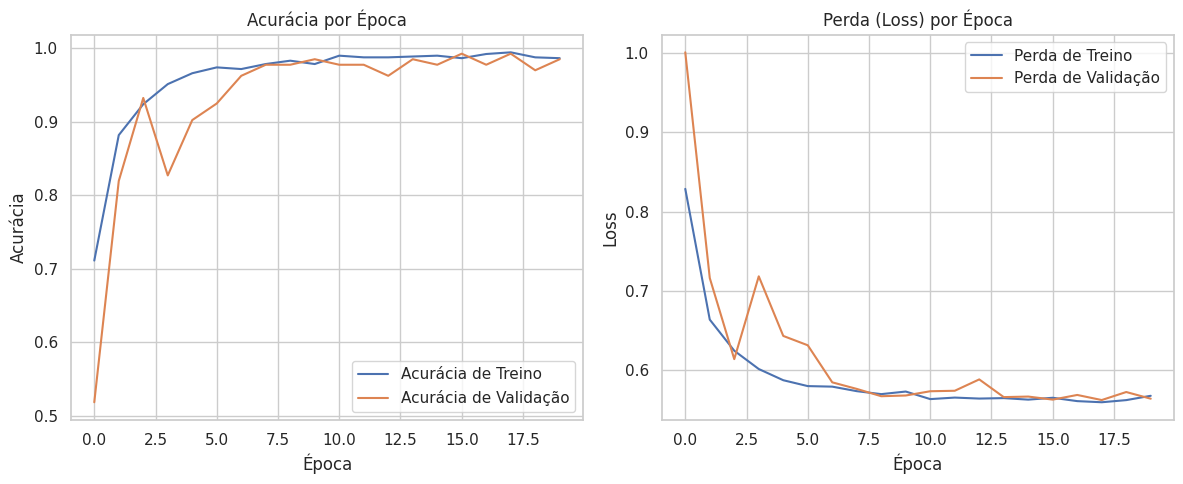

In [71]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(log['train_acc'], label='Acurácia de Treino')
plt.plot(log['val_acc'], label='Acurácia de Validação')
plt.title('Acurácia por Época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(log['train_loss'], label='Perda de Treino')
plt.plot(log['val_loss'], label='Perda de Validação')
plt.title('Perda (Loss) por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [72]:
classes = train_dataset.classes   # ['angular_leaf_spot', 'bean_rust', 'healthy']


def predict(image_path, model=model, transform=val_test_transform, device=device):
    """
    Carrega uma imagem do disco, aplica o mesmo pré-processamento usado na
    validação e retorna o índice da classe prevista e a probabilidade associada.
    """
    img = cv2.imread(image_path)

    if img is None:
        raise FileNotFoundError(f"Não foi possível ler a imagem: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # (3, 224, 224) -> (1, 3, 224, 224), pois o modelo espera um batch
    tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probs = model(tensor)              # o forward já aplica softmax
        prob, idx = torch.max(probs, 1)

    return idx.item(), prob.item()


# Desempenho do Conjunto de Teste
model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

print(f"Acurácia no conjunto de teste: {accuracy_score(y_true, y_pred):.4f}\n")

# Exemplo de uso da função predict
caminho_exemplo, label_real = test_dataset.data[random.randint(0,154)]
idx, prob = predict(caminho_exemplo)

print(f"Arquivo:         {os.path.basename(caminho_exemplo)}")
print(f"Classe prevista: {classes[idx]} ({prob*100:.2f}%)")
print(f"Classe real:     {classes[label_real]}")

Acurácia no conjunto de teste: 0.9740

Arquivo:         bean_rust_train.229.jpg
Classe prevista: bean_rust (100.00%)
Classe real:     bean_rust


#3 Predição, desempenho do modelo resnet18 e avaliação

In [73]:
classes = train_dataset.classes   # ['angular_leaf_spot', 'bean_rust', 'healthy']


def predict(image_path, model=model, transform=val_test_transform, device=device):
    """
    Carrega uma imagem do disco, aplica o mesmo pré-processamento usado na
    validação e retorna o índice da classe prevista e a probabilidade associada.
    """
    img = cv2.imread(image_path)

    if img is None:
        raise FileNotFoundError(f"Não foi possível ler a imagem: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # (3, 224, 224) -> (1, 3, 224, 224), pois o modelo espera um batch
    tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probs = model(tensor)              # o forward já aplica softmax
        prob, idx = torch.max(probs, 1)

    return idx.item(), prob.item()


# Desempenho do Conjunto de Teste
model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

print(f"Acurácia no conjunto de teste: {accuracy_score(y_true, y_pred):.4f}\n")

# Exemplo de uso da função predict
caminho_exemplo, label_real = test_dataset.data[random.randint(0,153)]
idx, prob = predict(caminho_exemplo)

print(f"Arquivo:         {os.path.basename(caminho_exemplo)}")
print(f"Classe prevista: {classes[idx]} ({prob*100:.2f}%)")
print(f"Classe real:     {classes[label_real]}")

Acurácia no conjunto de teste: 0.9740

Arquivo:         bean_rust_train.142.jpg
Classe prevista: bean_rust (99.51%)
Classe real:     bean_rust


In [74]:
classes = train_dataset.classes

print("\nRelatório de Classificação no Conjunto de Teste:")
print(classification_report(y_true, y_pred, target_names=classes))


Relatório de Classificação no Conjunto de Teste:
                   precision    recall  f1-score   support

angular_leaf_spot       0.98      0.94      0.96        49
        bean_rust       0.95      0.98      0.96        55
          healthy       1.00      1.00      1.00        50

         accuracy                           0.97       154
        macro avg       0.98      0.97      0.97       154
     weighted avg       0.97      0.97      0.97       154



## Matriz de Confusão

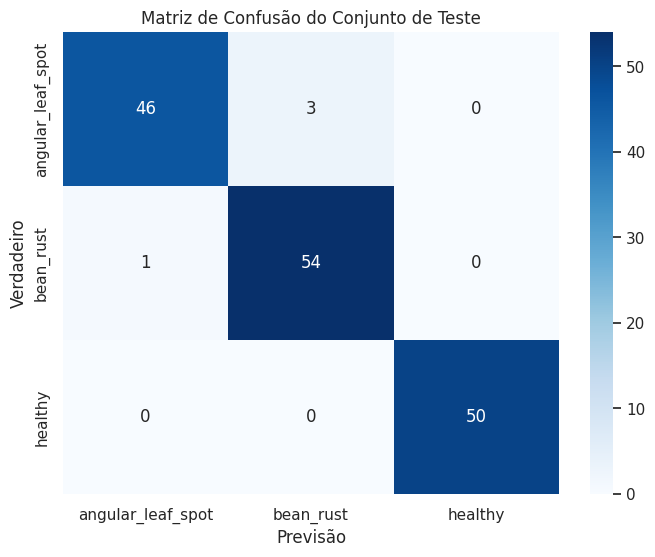

In [75]:
#matriz
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão do Conjunto de Teste')
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.show()

#Inspeção Visual

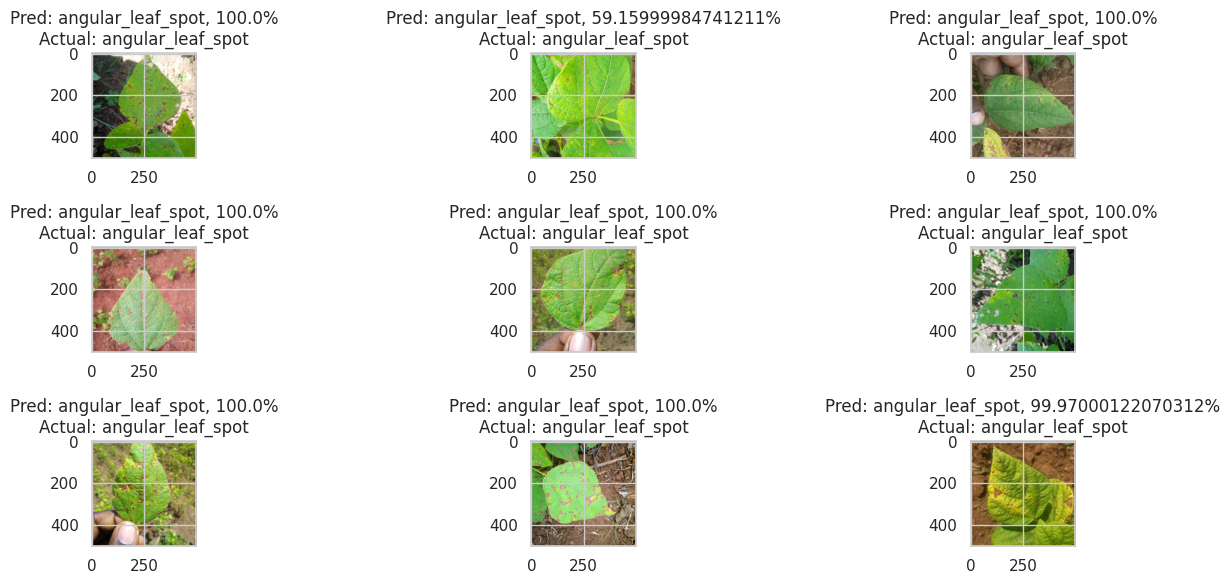

In [76]:
from sklearn.preprocessing import LabelEncoder

# Initialize and fit the LabelEncoder. The `classes` variable is available from a previous cell.
le = LabelEncoder()
le.fit(classes)

# Map the variables from the previous cells that contain the predictions, true labels, and probabilities
preds = y_pred
truth = y_true
probas = y_prob

pred_labels = le.inverse_transform(np.array(preds))
truth_labels = le.inverse_transform(np.array(truth))

index = 0

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 6))

for i in range(3):
    for j in range(3):
        # Correctly access the image path from test_dataset.data
        image_path = test_dataset.data[index][0]
        axes[i][j].imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
        # Format the probability to percentage
        axes[i][j].set_title("Pred: {}, {}%\nActual: {}".format(pred_labels[index], round(probas[index]*100, 2), truth_labels[index]))
        index += 1

plt.tight_layout()
plt.show()

###Visualização de exemplos mal classifcados

Foram encontrados 4 exemplos mal classificados.


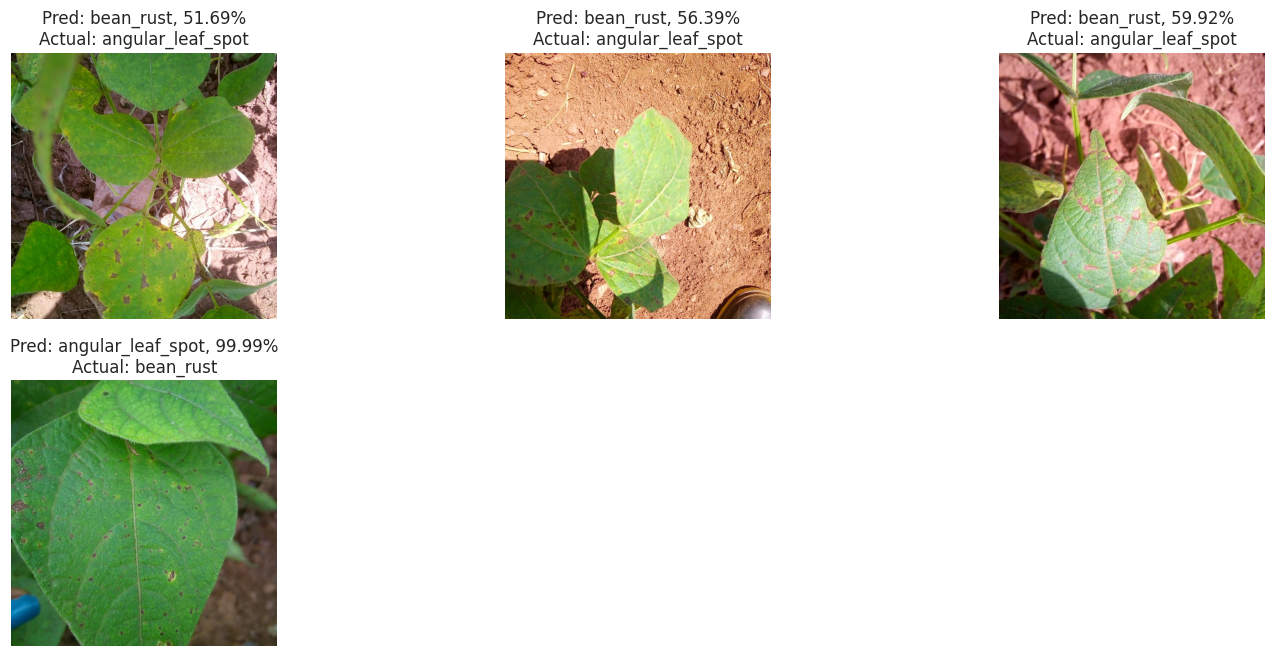

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Filtrar apenas os índices onde a predição está errada
misclassified_indices = np.where(np.array(y_pred) != np.array(y_true))[0]

if len(misclassified_indices) == 0:
    print("Nenhum exemplo mal classificado encontrado no conjunto de teste!")
elif len(misclassified_indices) < 9:
    print(f"Foram encontrados {len(misclassified_indices)} exemplos mal classificados.")
    display_indices = misclassified_indices
else:
    print(f"Foram encontrados {len(misclassified_indices)} exemplos mal classificados. Exibindo 9 aleatoriamente:")
    display_indices = np.random.choice(misclassified_indices, 9, replace=False)


if len(display_indices) > 0:
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
    axes = axes.flatten() # Achata o array de eixos para facilitar a iteração

    for i, idx in enumerate(display_indices):
        image_path = test_dataset.data[idx][0]
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        pred_label = le.inverse_transform([y_pred[idx]])[0]
        true_label = le.inverse_transform([y_true[idx]])[0]
        prob = y_prob[idx]

        axes[i].imshow(img)
        axes[i].set_title(f"Pred: {pred_label}, {prob*100:.2f}%\nActual: {true_label}")
        axes[i].axis('off') # Remover eixos para melhor visualização da imagem

    # Esconder eixos vazios se houver menos de 9 imagens
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("Não há exemplos mal classificados para exibir.")